# Logistic Regression Model for Student Pass/Fail Prediction

This notebook demonstrates how to create a logistic regression model to predict whether a student will pass or fail based on the number of hours they studied.

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Step 2: Prepare the dataset
# Create sample data: hours studied and pass/fail labels (1 = pass, 0 = fail)
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5],
    'pass_fail': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)
print('Dataset preview:')
print(df.head())

Dataset preview:
   hours_studied  pass_fail
0            1.0          0
1            2.0          0
2            3.0          0
3            4.0          0
4            5.0          1


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hours_studied  20 non-null     float64
 1   pass_fail      20 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes
None

Summary statistics:
       hours_studied  pass_fail
count       20.00000  20.000000
mean         5.75000   0.700000
std          2.95804   0.470162
min          1.00000   0.000000
25%          3.37500   0.000000
50%          5.75000   1.000000
75%          8.12500   1.000000
max         10.50000   1.000000


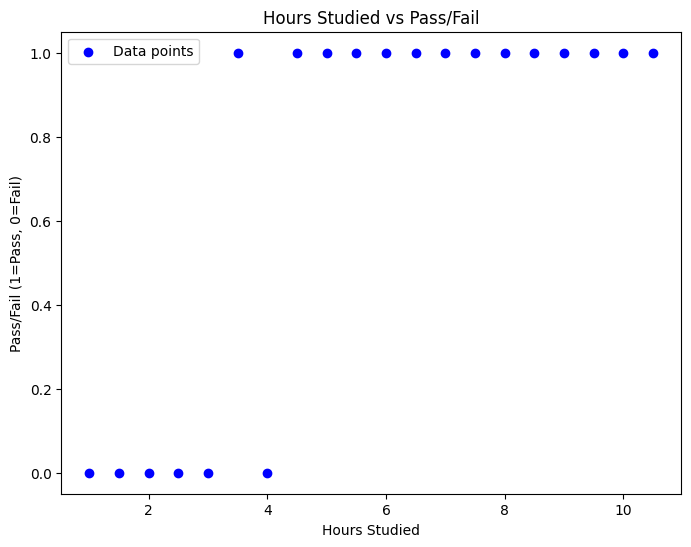

In [3]:
# Step 3: Explore the dataset
print('Dataset information:')
print(df.info())
print('\nSummary statistics:')
print(df.describe())

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(df['hours_studied'], df['pass_fail'], color='blue', label='Data points')
plt.xlabel('Hours Studied')
plt.ylabel('Pass/Fail (1=Pass, 0=Fail)')
plt.title('Hours Studied vs Pass/Fail')
plt.legend()
plt.show()

In [4]:
# Step 4: Split the data into training and test sets
X = df[['hours_studied']]
y = df['pass_fail']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set size:', len(X_train))
print('Test set size:', len(X_test))

Training set size: 16
Test set size: 4


In [5]:
# Step 5: Train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)
print('Model trained successfully.')
print('Model coefficients:', model.coef_)
print('Model intercept:', model.intercept_)

Model trained successfully.
Model coefficients: [[1.20031074]]
Model intercept: [-4.39786779]


In [6]:
# Step 6: Evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy on test set:', accuracy)
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy on test set: 1.0

Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [7]:
# Step 7: Prepare new test data for prediction
# New samples of hours studied
new_hours = [[2], [5], [8], [12]]
print('New test samples (hours studied):', [h[0] for h in new_hours])

New test samples (hours studied): [2, 5, 8, 12]


In [8]:
# Step 8: Predict pass/fail for the new test data
predictions = model.predict(new_hours)
for hours, pred in zip(new_hours, predictions):
    result = 'Pass' if pred == 1 else 'Fail'
    print(f'Student who studied {hours[0]} hours is predicted to: {result}')

Student who studied 2 hours is predicted to: Fail
Student who studied 5 hours is predicted to: Pass
Student who studied 8 hours is predicted to: Pass
Student who studied 12 hours is predicted to: Pass


d:\Development\GitRads\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Step 9: Visualize the model and predictions
# Plot the logistic regression curve
X_range = np.linspace(0, 12, 100).reshape(-1, 1)
y_prob = model.predict_proba(X_range)[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df['hours_studied'], df['pass_fail'], color='blue', label='Training data')
plt.plot(X_range, y_prob, color='red', label='Logistic regression curve')
plt.scatter([h[0] for h in new_hours], predictions, color='green', marker='x', s=100, label='New predictions')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing / Actual Outcome')
plt.title('Logistic Regression: Predicting Pass/Fail Based on Study Hours')
plt.legend()
plt.show()